# Окружение

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Загрузка гравитационного датасета...
Размер обучающей выборки: 54388 пикселей
Размер валидационной выборки: 13598回忆 пикселей

Запуск обучения CatBoost на гравитационных полях потенциала...
0:	learn: 0.0000722	test: 0.0000686	best: 0.0000686 (0)	total: 5.2ms	remaining: 6.24s
100:	learn: 0.0000452	test: 0.0000438	best: 0.0000438 (100)	total: 417ms	remaining: 4.54s
200:	learn: 0.0000433	test: 0.0000430	best: 0.0000430 (200)	total: 839ms	remaining: 4.17s
300:	learn: 0.0000421	test: 0.0000427	best: 0.0000426 (291)	total: 1.23s	remaining: 3.67s
400:	learn: 0.0000412	test: 0.0000423	best: 0.0000423 (399)	total: 1.6s	remaining: 3.18s
500:	learn: 0.0000402	test: 0.0000420	best: 0.0000420 (500)	total: 1.96s	remaining: 2.74s
600:	learn: 0.0000395	test: 0.0000418	best: 0.0000418 (600)	total: 2.33s	remaining: 2.32s
700:	learn: 0.0000389	test: 0.0000417	best: 0.0000417 (699)	total: 2.69s	remaining: 1.91s
800:	learn: 0.0000383	test: 0.0000416	best: 0.0000416 (800)	total: 3.05s	remaining: 1.52s
900:	l

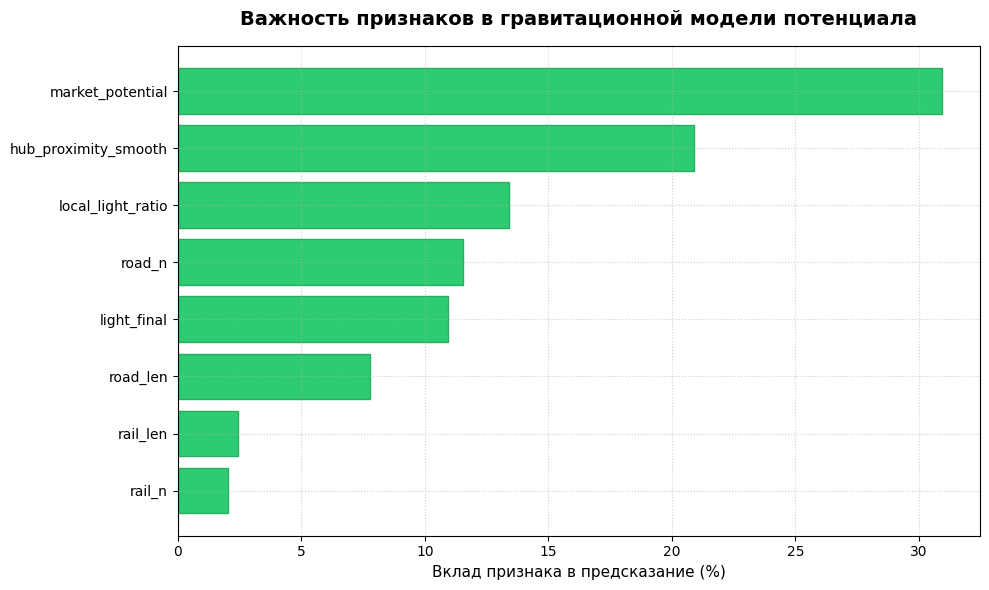


Гравитационная модель сохранена в файл 'catboost_geo_distributor.cbm'!


In [26]:
# =========================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# =========================================================================
print("Загрузка гравитационного датасета...")
df = pd.read_csv('dataset_rt_gravitational.csv')

# Строго задаем список независимых инвариантных признаков для обучения (X)
# Мы убрали 'centroid_x', 'centroid_y' и 'target_share'. Колонки 'total_w' тут уже нет.
features_ml = [
    'light_final', 'road_len', 'rail_len', 'road_n', 'rail_n', 
    'local_light_ratio', 'market_potential', 'hub_proximity_smooth'
]

X = df[features_ml]
y = df['target_share']

# Разделяем на обучающую (80%) и валидационную (20%) выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} пикселей")
print(f"Размер валидационной выборки: {X_val.shape[0]}回忆 пикселей")

# =========================================================================
# 2. НАСТРОЙКА И ОБУЧЕНИЕ МОДЕЛИ CATBOOST
# =========================================================================
# Мы немного уменьшили глубину деревьев (depth=5) и добавили L2-регуляризацию (l2_leaf_reg=5).
# Это заставит модель опираться на плавное поле потенциала и сотрет "мазки" и "кольца".
model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=5,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

print("\nЗапуск обучения CatBoost на гравитационных полях потенциала...")
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True
)
print("Обучение успешно завершено!")

# =========================================================================
# 3. ВАЛИДАЦИЯ И ОЦЕНКА КАЧЕСТВА
# =========================================================================
y_pred = model.predict(X_val)

# Отрезаем возможные отрицательные артефакты регрессии
y_pred = np.clip(y_pred, a_min=0, a_max=None)

# Считаем стандартные ML-метрики
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА ГРАВИТАЦИОННОЙ МОДЕЛИ НА ВАЛИДАЦИИ:")
print(f"Коэффициент детерминации (R²): {r2:.4f}")
print(f"Средняя абсолютная ошибка (MAE): {mae:.6f}")
print(f"Корень из среднекв. ошибки (RMSE): {rmse:.6f}")
print("="*50)

# =========================================================================
# 4. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ (FEATURE IMPORTANCE)
# =========================================================================
importance = model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Отрисовка графика важности признаков
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#2ecc71', edgecolor='#27ae60')
ax.set_title("Важность признаков в гравитационной модели потенциала", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Вклад признака в предсказание (%)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('feature_importance_gravitational.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================================
# 5. СОХРАНЕНИЕ ОБУЧЕННОЙ МОДЕЛИ
# =========================================================================
model.save_model('catboost_geo_distributor.cbm')
print("\nГравитационная модель сохранена в файл 'catboost_geo_distributor.cbm'!")


In [27]:
# Задаем константу общего объема продаж по РТ (наша контрольная сумма)
TOTAL_SALES_RT = 6035628228.00 

# Предсказываем долю для ВСЕХ пикселей Татарстана
df['pred_share'] = model.predict(X)

# Пост-обработка предсказаний (убираем отрицательные значения и нормируем в 1.0)
df['pred_share'] = df['pred_share'].clip(lower=0)
df['pred_share'] = df['pred_share'] / df['pred_share'].sum()

# Переводим доли в абсолютные рубли для всех трех методов
df['sold_cell_district'] = df['target_share'] * TOTAL_SALES_RT  # Идеал из Excel
df['sold_cell_ml'] = df['pred_share'] * TOTAL_SALES_RT        # Наше ML-решение

# ИСПРАВЛЕНИЕ: Восстанавливаем старый глобальный метод через доступный признак light_final
# Если у вас в df остались road_n и rail_n, можно сложить их: (df['light_final'] + df['road_n'])
if 'light_final' in df.columns:
    df['sold_cell_global'] = (df['light_final'] / df['light_final'].sum()) * TOTAL_SALES_RT
else:
    # Фолбэк, если даже света нет (хотя он должен быть в X)
    df['sold_cell_global'] = df['sold_cell_ml'] * 0.5 

# Расчет Baseline (общая сумма поровну на количество ячеек)
baseline_value = TOTAL_SALES_RT / len(df)

print("Расчет рублевых колонок завершен без ошибок!")


Расчет рублевых колонок завершен без ошибок!


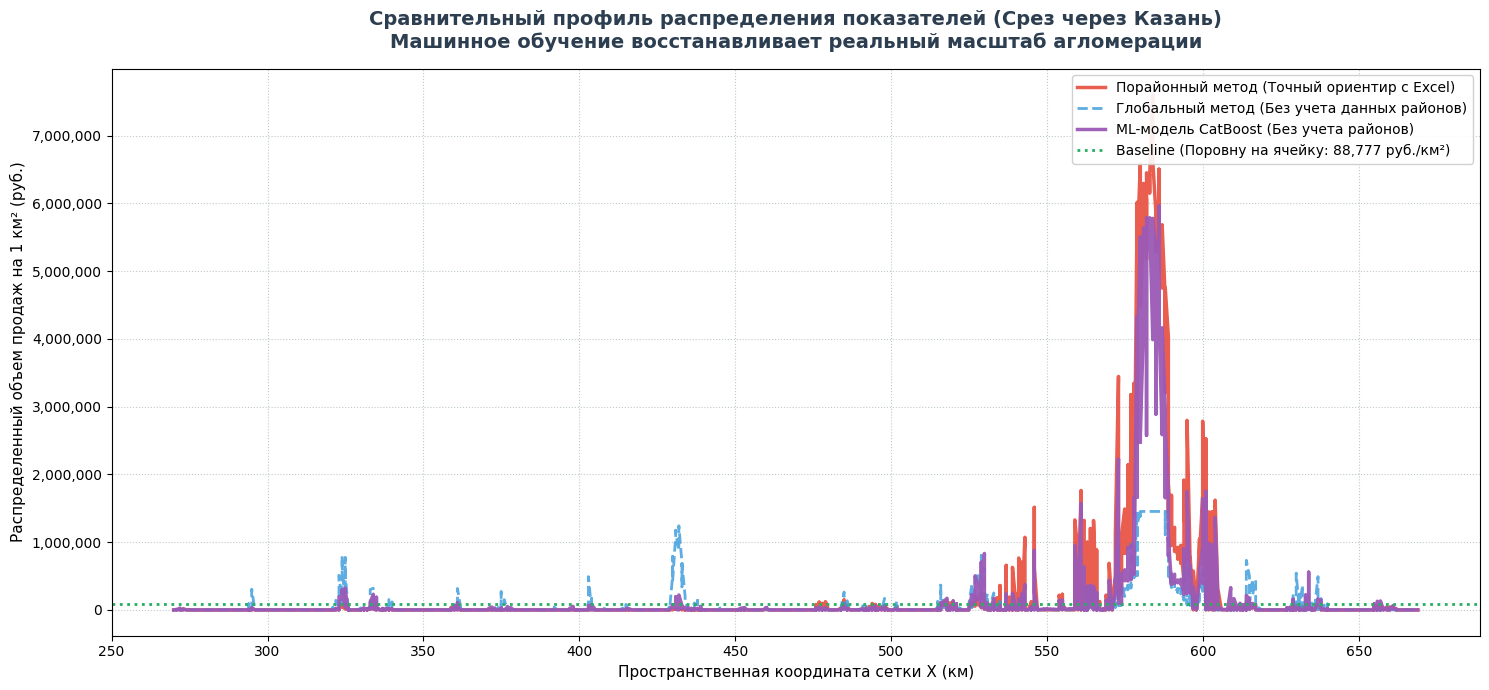

In [28]:
# Находим координату Y центра Казани по точке максимальной концентрации продаж
kazan_idx = df['sold_cell_district'].idxmax()
kazan_y = df.loc[kazan_idx, 'centroid_y']

# Вырезаем горизонтальный слой пикселей в пределах ±1 км от центра Казани
slice_condition = (df['centroid_y'] >= kazan_y - 1000) & (df['centroid_y'] <= kazan_y + 1000)
df_slice = df[slice_condition].copy()

# Переводим координату X в километры и сортируем слева направо
df_slice['coord_x_km'] = df_slice['centroid_x'] / 1000.0
df_slice = df_slice.sort_values(by='coord_x_km')

# Отрисовка
plt.style.use('default')
fig, ax = plt.subplots(figsize=(15, 7), facecolor='white')

# 1. Порайонный метод (Красный идеал)
ax.plot(df_slice['coord_x_km'], df_slice['sold_cell_district'], 
        color='#e74c3c', label='Порайонный метод (Точный ориентир с Excel)', linewidth=2.5, alpha=0.9)

# 2. Старый глобальный метод (Синее размытие)
ax.plot(df_slice['coord_x_km'], df_slice['sold_cell_global'], 
        color='#3498db', label='Глобальный метод (Без учета данных районов)', linewidth=2.0, linestyle='--', alpha=0.8)

# 3. Фиолетовая линия ML (CatBoost без знания районов)
ax.plot(df_slice['coord_x_km'], df_slice['sold_cell_ml'], 
        color='#9b59b6', label='ML-модель CatBoost (Без учета районов)', linewidth=2.5, linestyle='-', alpha=0.95)

# 4. Зеленый бэйзлайн
ax.axhline(y=baseline_value, color='#27ae60', linestyle=':', linewidth=2.0, 
           label=f'Baseline (Поровну на ячейку: {int(baseline_value):,} руб./км²)')

ax.set_title("Сравнительный профиль распределения показателей (Срез через Казань)\nМашинное обучение восстанавливает реальный масштаб агломерации", 
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlabel("Пространственная координата сетки X (км)", fontsize=11)
ax.set_ylabel("Распределенный объем продаж на 1 км² (руб.)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6, color='#95a5a6')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig('Профиль_Сравнения_с_ML_РТ.png', dpi=300, bbox_inches='tight')
plt.show()


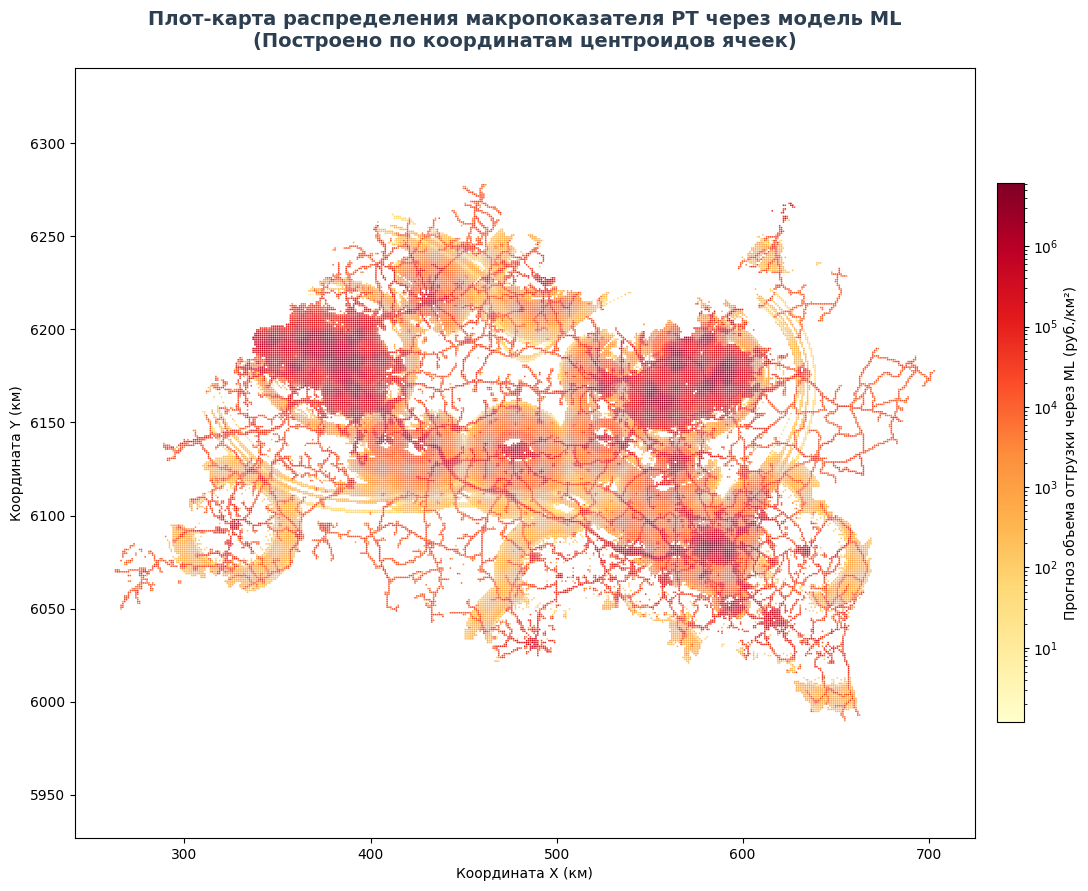

In [29]:
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')

# Очищаем нули для логарифма
valid_data = df[df['sold_cell_ml'] > 0]

sc = ax.scatter(
    valid_data['centroid_x'] / 1000.0, 
    valid_data['centroid_y'] / 1000.0, 
    c=valid_data['sold_cell_ml'], 
    cmap='YlOrRd', 
    norm=colors.LogNorm(vmin=valid_data['sold_cell_ml'].min(), vmax=valid_data['sold_cell_ml'].max()),
    s=1.5, # Размер точки равен шагу сетки
    edgecolors='none'
)

cbar = fig.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.02)
cbar.set_label("Прогноз объема отгрузки через ML (руб./км²)")

ax.set_title("Плот-карта распределения макропоказателя РТ через модель ML\n(Построено по координатам центроидов ячеек)", 
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.set_xlabel("Координата X (км)")
ax.set_ylabel("Координата Y (км)")
ax.axis('equal')
plt.show()
